In [1]:
from pathlib import Path
from collections import namedtuple

In [2]:
Args = namedtuple("args", ["input", "output"])
args = Args("/home/vruiz/gdrive_TomogramDenoising/tomograms/Corbel2301_block2_June2019_crop_ali_crop.mrc",
            "corbel_small_SFSC.pdf")

In [3]:
import time
from collections import namedtuple
try:
    from skimage import io as skimage_io
except:
    !pip install scikit-image
    from skimage import io as skimage_io
from self_fourier_shell_correlation import fsc_utils as fsc
import numpy as np
import matplotlib.pyplot as plt
import mrcfile

In [4]:
# apt install cm-super-minimal
# apt install dvipng
plt.rcParams.update({
    "text.usetex": True,
    #"font.family": "Helvetica",
    "font.family": "Serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amsfonts}"
})

In [5]:
vol_MRC = mrcfile.open(args.input)
vol = vol_MRC.data
print(f"shape={vol.shape}")

shape=(100, 800, 800)


In [6]:
#vol = vol[0:52, 0:2028, 0:2652]

In [7]:
#print(f"shape={vol.shape}")

In [8]:
def compute_averaged_sfsc(volume, block_size, step_size=None):
    """
    Computes the averaged Self Fourier Shell Correlation (SFSC) over cubic blocks
    extracted from a non-cubic 3D volume.

    Parameters:
    -----------
    volume : np.ndarray
        The 3D input volume (can be non-cubic).
    block_size : int
        The size of the cubic block (block_size x block_size x block_size).
    sfsc_func : callable
        A function that takes a cubic 3D numpy array and returns its SFSC (as a 1D numpy array).
    step_size : int, optional
        The step size for the sliding window. Defaults to block_size (non-overlapping).
        Set this to a smaller value (e.g., block_size // 2) for overlapping blocks.

    Returns:
    --------
    np.ndarray
        The averaged SFSC curve.
    """
    if step_size is None:
        step_size = block_size

    z_dim, y_dim, x_dim = volume.shape
    sfsc_results = []

    # Iterate over the volume in 3D
    for z in range(0, z_dim - block_size + 1, step_size):
        for y in range(0, y_dim - block_size + 1, step_size):
            for x in range(0, x_dim - block_size + 1, step_size):
                
                # Extract the cubic block
                block = volume[z:z+block_size, y:y+block_size, x:x+block_size]
                
                # Compute the SFSC for the current block
                freqs, block_curve = fsc.get_SFSC_curve(block)
                sfsc_results.append(block_curve)

    # Catch the edge case where the volume is too small
    if not sfsc_results:
        raise ValueError(f"Volume dimensions {volume.shape} are smaller than the block size {block_size}.")

    # Stack all 1D SFSC arrays into a 2D array and average them along the column axis (axis 0)
    averaged_sfsc = np.mean(sfsc_results, axis=0)

    return freqs, averaged_sfsc

In [9]:
spatial_freq, fsc_values = compute_averaged_sfsc(vol, block_size=100, step_size=100)

compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fourier_shell_correlation.shape=(100, 100, 50)
compute_fourier_shell_correlation.shape=(100, 50, 100)
compute_fourier_shell_correlation.shape=(50, 100, 100)
compute_fo

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fsc(spatial_freq, fsc_values, X_label, Y_label, title, show_thresholds=True):
    """                                                                                                                        
    Plot the Fourier Shell Correlation (FSC) curve and annotate both 0.5 and 0.143 threshold crossings.                                                                                                
    """
    plt.plot(spatial_freq, fsc_values, label='SFSC', color='blue', linewidth=2)
    
    if show_thresholds:
        # Define the thresholds we want to plot and analyze
        threshold_configs = [
            {'val': 0.5, 'line_color': 'g', 'vert_color': 'purple', 'name': '0.5'},
            {'val': 0.143, 'line_color': 'r', 'vert_color': 'darkorange', 'name': '0.143'}
        ]
        
        x_arr = np.asarray(spatial_freq)
        y_arr = np.asarray(fsc_values)
        
        for config in threshold_configs:
            thresh = config['val']
            
            # Plot the horizontal threshold line
            plt.axhline(y=thresh, color=config['line_color'], linestyle='--', label=f'{thresh} threshold')
            
            # Find where the curve drops below the threshold
            crossings = np.where(np.diff(np.signbit(y_arr - thresh)))[0]
            
            if len(crossings) > 0:
                idx = crossings[0]
                
                # Bounding points for linear interpolation
                x1, y1 = x_arr[idx], y_arr[idx]
                x2, y2 = x_arr[idx + 1], y_arr[idx + 1]
                
                # Calculate precise intersection point
                x_cross = x1 + (thresh - y1) * (x2 - x1) / (y2 - y1)
                
                # Plot the vertical line at the intersection
                plt.axvline(
                    x=x_cross, 
                    color=config['vert_color'], 
                    linestyle=':', 
                    label=f'Resolution at {config["name"]}: {x_cross:.3f}'
                )
                
                # Add text annotation just above the intersection point
                plt.text(
                    x=x_cross, 
                    y=thresh + 0.02,  # Dynamically shifts slightly above the respective line
                    s=f'{x_cross:.3f}', 
                    color=config['vert_color'], 
                    ha='left', 
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
                )
            else:
                print(f"Note: The FSC curve never crosses the {thresh} threshold.")

    plt.xlabel(X_label)
    plt.ylabel(Y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(args.output, bbox_inches='tight')
    plt.show()

Note: The FSC curve never crosses the 0.143 threshold.


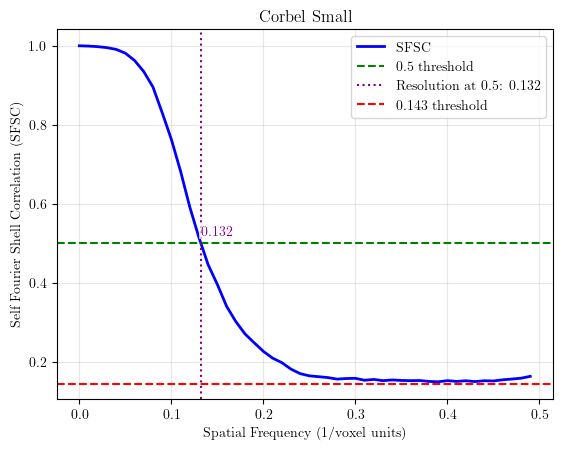

In [12]:
plot_fsc(spatial_freq, fsc_values, "Spatial Frequency (1/voxel units)", "Self Fourier Shell Correlation (SFSC)", "Corbel Small")

In [13]:
avg = []
for i in range(vol.shape[0]):
    EOS_freq, EOS_c_avg = fsc.get_SFRC_curve__even_odd(vol[i])
    avg.append(EOS_c_avg)
avg_sfrc = np.mean(avg, axis=0)

compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlation.shape=(400, 800)
compute_fourier_shell_correlation.shape=(800, 400)
compute_fourier_shell_correlati

Note: The FSC curve never crosses the 0.143 threshold.


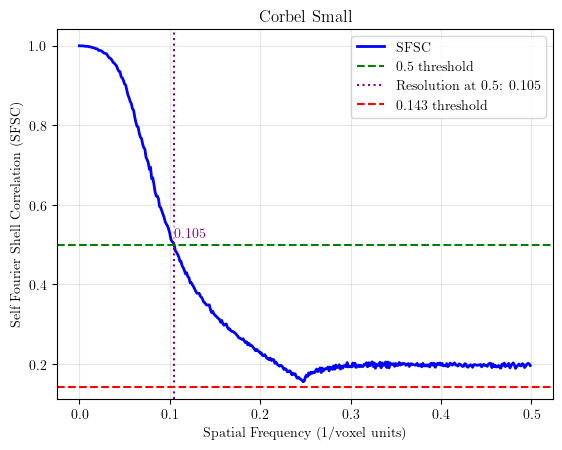

In [16]:
plot_fsc(EOS_freq, avg_sfrc, "Spatial Frequency (1/voxel units)", "Self Fourier Shell Correlation (SFSC)", "Corbel Small")